In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Fixing random state for reproducibility
np.random.seed(19680801)

# Some random data
x = np.random.randn(1_000)
y = np.random.randn(1_000)


def scatter_hist(x, y, ax, ax_histx, ax_histy):
    # no labels
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)

    # the scatter plot
    ax.scatter(x, y)

    # now determine nice limits by hand:
    binwidth = 0.25
    xymax = max(np.max(np.abs(x)), np.max(np.abs(y)))
    lim = (int(xymax / binwidth) + 1) * binwidth

    bins = np.arange(-lim, lim + binwidth, binwidth)
    ax_histx.hist(x, bins=bins)
    ax_histy.hist(y, bins=bins, orientation="horizontal")

#### Definine the Axes positions using `subplot_mosaic`

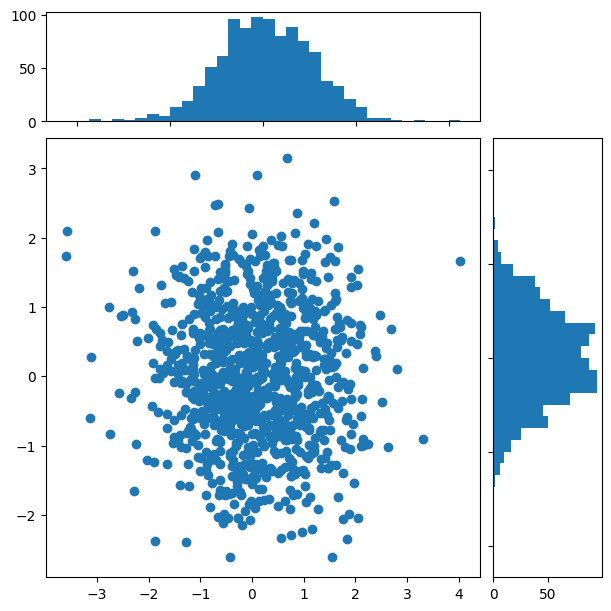

In [3]:
fig, axs = plt.subplot_mosaic(
    [
        ["histx", "."],
        ["scatter", "histy"],
    ],
    figsize=(6, 6),
    width_ratios=(4, 1),
    height_ratios=(1, 4),
    layout="constrained",
)

scatter_hist(x, y, axs["scatter"], axs["histx"], axs["histy"])

#### Defining the Axes positions using `inset_axes`

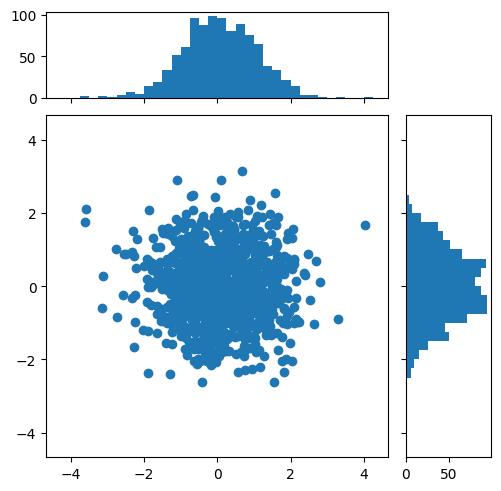

In [5]:
# Create a Figure, which doesn't have to be square
fig = plt.figure(layout="constrained")

# Create the main Axes
ax = fig.add_subplot()

# The main Axes aspect can be fixed
ax.set_aspect("equal")

# Create marginal Axes, which have 25% of the size of the main Axes.
# Note that the inset Axes are positioned "outside" (on the right and the top)
# of the main Axes, by specifying Axes coordinates greater than 1. Axes
# coordinates less than 0, would likewise specify positions on the left and
# the bottom of the main Axes.
ax_histx = ax.inset_axes([0, 1.05, 1, 0.25], sharex=ax)
ax_histy = ax.inset_axes([1.05, 0, 0.25, 1], sharey=ax)

# Draw the scatter plot and marginals
scatter_hist(x, y, ax, ax_histx, ax_histy)